# Notebook 06 — Federated Learning with Flower and FedAvg

This notebook implements a privacy-preserving federated learning simulation
for network intrusion detection using four clients and the FedAvg algorithm.

In [1]:
# ============================================================
# VERIFY PYTHON, FLOWER, AND PYTORCH INSTALLATION
# ============================================================

import sys
import flwr as fl
import ray
import torch

print("Python version:", sys.version.split()[0])
print("Flower version:", fl.__version__)
print("Ray version:", ray.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python version: 3.13.14
Flower version: 1.35.0
Ray version: 2.58.0
PyTorch version: 2.13.0+cpu
CUDA available: False


In [2]:
# ============================================================
# LOAD PROCESSED TRAINING AND TEST DATA
# ============================================================

from pathlib import Path
import pandas as pd

# Update these paths only if your notebook is stored elsewhere.
TRAIN_PATH = Path("../data/processed/CICIDS2017_train.csv")
TEST_PATH = Path("../data/processed/CICIDS2017_test.csv")

# Confirm that both processed files exist.
assert TRAIN_PATH.exists(), f"Training file not found: {TRAIN_PATH.resolve()}"
assert TEST_PATH.exists(), f"Test file not found: {TEST_PATH.resolve()}"

# Load the processed datasets created in Notebook 03–05.
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nFirst five training columns:")
print(train_df.columns[:5].tolist())

print("\nLast five training columns:")
print(train_df.columns[-5:].tolist())

Training data shape: (2016638, 49)
Test data shape: (504160, 49)

First five training columns:
['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Length_of_Fwd_Packets', 'Fwd_Packet_Length_Max']

Last five training columns:
['Active_Max', 'Active_Min', 'Idle_Std', 'Original_Row_ID', 'Label']


In [3]:
# ============================================================
# SEPARATE FEATURES, ENCODE LABELS, AND STANDARDIZE FEATURES
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Find the target-label column.
label_candidates = [
    "Label",
    "label",
    "Class",
    "class",
    "Target",
    "target",
]

LABEL_COLUMN = next(
    (
        column
        for column in label_candidates
        if column in train_df.columns
    ),
    None,
)

assert LABEL_COLUMN is not None, (
    "Label column was not found. Check train_df.columns.tolist()."
)

# Confirm train and test files contain the same columns.
assert set(train_df.columns) == set(test_df.columns), (
    "Train and test datasets have different columns."
)

# Separate input features from the target label.
feature_columns = [
    column
    for column in train_df.columns
    if column != LABEL_COLUMN
]

# Encode target labels as integers: 0, 1, 2, ...
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df[LABEL_COLUMN]
).astype(np.int64)

y_test = label_encoder.transform(
    test_df[LABEL_COLUMN]
).astype(np.int64)

# Convert features to numeric arrays.
X_train = train_df[feature_columns].to_numpy(
    dtype=np.float32
)

X_test = test_df[feature_columns].to_numpy(
    dtype=np.float32
)

# Standardize features using training-data statistics only.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(
    np.float32
)

X_test = scaler.transform(X_test).astype(
    np.float32
)

# Store model dimensions.
NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = len(label_encoder.classes_)

print("✅ Step 5 complete: Features and labels are ready.")
print("Label column:", LABEL_COLUMN)
print("Number of input features:", NUM_FEATURES)
print("Number of classes:", NUM_CLASSES)
print("Class labels:", list(label_encoder.classes_))

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

✅ Step 5 complete: Features and labels are ready.
Label column: Label
Number of input features: 48
Number of classes: 15
Class labels: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

X_train shape: (2016638, 48)
y_train shape: (2016638,)
X_test shape: (504160, 48)
y_test shape: (504160,)


In [4]:
# ============================================================
# SPLIT TRAINING DATA INTO FOUR SIMULATED ORGANIZATIONS
# Each client receives a separate, stratified partition.
# ============================================================

from sklearn.model_selection import StratifiedKFold

SEED = 42
NUM_CLIENTS = 4

client_partitions = []

splitter = StratifiedKFold(
    n_splits=NUM_CLIENTS,
    shuffle=True,
    random_state=SEED,
)

for client_id, (_, client_indices) in enumerate(
    splitter.split(X_train, y_train),
    start=1,
):
    X_client = X_train[client_indices]
    y_client = y_train[client_indices]

    client_partitions.append((X_client, y_client))

    print(
        f"Client {client_id}: "
        f"{len(X_client):,} records | "
        f"Class distribution: {np.bincount(y_client)}"
    )

Client 1: 504,160 records | Class distribution: [419012    390  25602   2057  34570   1045   1077   1186      2      7
  18139    644    294      5    130]
Client 2: 504,160 records | Class distribution: [419011    389  25603   2058  34569   1045   1077   1187      3      7
  18138    644    294      4    131]
Client 3: 504,159 records | Class distribution: [419011    389  25603   2057  34569   1046   1077   1186      2      7
  18139    644    294      4    131]
Client 4: 504,159 records | Class distribution: [419011    390  25603   2057  34569   1046   1077   1186      2      8
  18139    643    294      4    130]


In [5]:
# ============================================================
# NON-IID CLIENT PARTITION — LABEL DISTRIBUTION SKEW
# ============================================================

NUM_CLIENTS = 4
NUM_CLASSES = len(np.unique(y_train))

SEED = 42
rng = np.random.default_rng(SEED)

# Client specialization weights
client_preferences = np.ones((NUM_CLIENTS, NUM_CLASSES))

# Client 1: Benign + DoS
client_preferences[0, [0, 2, 3, 4, 5, 6]] = 5.0

# Client 2: Benign + PortScan
client_preferences[1, [0, 10]] = 5.0

# Client 3: Benign + Brute Force
client_preferences[2, [0, 7, 11, 12]] = 5.0

# Client 4: Benign + Web Attacks
client_preferences[3, [0, 12, 13, 14]] = 5.0

# Collect indices belonging to each class
class_indices = {
    class_id: np.flatnonzero(y_train == class_id)
    for class_id in range(NUM_CLASSES)
}

non_iid_client_indices = [[] for _ in range(NUM_CLIENTS)]

# Allocate each class across clients
for class_id, indices in class_indices.items():

    indices = indices.copy()
    rng.shuffle(indices)

    weights = client_preferences[:, class_id]
    probabilities = weights / weights.sum()

    counts = rng.multinomial(len(indices), probabilities)

    start = 0

    for client_id, count in enumerate(counts):
        client_indices = indices[start:start + count]
        non_iid_client_indices[client_id].extend(client_indices.tolist())
        start += count

# Create client datasets
non_iid_client_partitions = []

for client_id in range(NUM_CLIENTS):

    indices = np.array(non_iid_client_indices[client_id])

    rng.shuffle(indices)

    X_client = X_train[indices]
    y_client = y_train[indices]

    non_iid_client_partitions.append((X_client, y_client))

    print(
        f"Client {client_id + 1}: "
        f"{len(X_client):,} records | "
        f"Class distribution: {np.bincount(y_client, minlength=NUM_CLASSES)}"
    )

Client 1: 591,359 records | Class distribution: [419755    393  64008   5091  86553   2620   2686    609      2      4
   9147    322     91      1     77]
Client 2: 498,171 records | Class distribution: [418873    422  12848   1066  17290    568    554    566      3      9
  45506    304    105      3     54]
Client 3: 465,146 records | Class distribution: [418783    386  12689   1040  17084    474    532   2931      2      8
   9021   1635    475      4     82]
Client 4: 461,962 records | Class distribution: [418634    357  12866   1032  17350    520    536    639      2      8
   8881    314    505      9    309]


In [6]:
# ============================================================
# VALIDATE NON-IID PARTITION
# ============================================================

global_counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES
)

client_total = sum(
    len(y_client)
    for _, y_client in non_iid_client_partitions
)

assert client_total == len(y_train), (
    "Non-IID partition does not contain all training samples."
)

# Verify that no sample index was accidentally duplicated.
all_client_indices = np.concatenate(
    non_iid_client_indices
)

assert len(all_client_indices) == len(y_train)
assert len(np.unique(all_client_indices)) == len(y_train)

print("✅ All training samples assigned exactly once.")
print("Total samples:", client_total)
print("Original samples:", len(y_train))

✅ All training samples assigned exactly once.
Total samples: 2016638
Original samples: 2016638


In [7]:
# ============================================================
# SAVE NON-IID CLIENT CLASS DISTRIBUTION
# ============================================================

from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

distribution_rows = []

for client_id, (_, y_client) in enumerate(
    non_iid_client_partitions,
    start=1
):
    counts = np.bincount(
        y_client,
        minlength=NUM_CLASSES
    )

    total = counts.sum()

    for class_id in range(NUM_CLASSES):
        distribution_rows.append({
            "Client": client_id,
            "Class_ID": class_id,
            "Class_Label": label_encoder.classes_[class_id],
            "Samples": int(counts[class_id]),
            "Proportion": float(counts[class_id] / total),
        })

non_iid_distribution_df = pd.DataFrame(
    distribution_rows
)

distribution_path = (
    RESULTS_DIR /
    "non_iid_client_class_distribution.csv"
)

non_iid_distribution_df.to_csv(
    distribution_path,
    index=False
)

print(
    f"✅ Saved: {distribution_path}"
)

✅ Saved: ..\results\non_iid_client_class_distribution.csv


In [8]:
# ============================================================
# FEDERATED TRAINING CONFIGURATION
# ============================================================

import random
import torch
from torch.utils.data import DataLoader, TensorDataset

RANDOM_SEED = 42
NUM_ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 256
LEARNING_RATE = 0.001

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# CPU is sufficient for this initial federated simulation.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training device:", DEVICE)
print("Federated rounds:", NUM_ROUNDS)
print("Local epochs per client:", LOCAL_EPOCHS)


def create_data_loader(X, y, shuffle=False):
    """
    Convert NumPy feature and label arrays into a PyTorch DataLoader.
    """
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )

# ============================================================
# CALCULATE CLASS WEIGHTS
# This prevents the model from ignoring minority attack classes.
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32,
).to(DEVICE)

print("Class weights:", CLASS_WEIGHTS.cpu().numpy())
print("Class imbalance handling is configured.")

Training device: cpu
Federated rounds: 10
Local epochs per client: 2
Class weights: [8.02141577e-02 8.62917404e+01 1.31277430e+00 1.63376522e+01
 9.72269654e-01 3.21479034e+01 3.12076454e+01 2.83335152e+01
 1.49380596e+04 4.63594922e+03 1.85297406e+00 5.22106934e+01
 1.14321884e+02 7.90838428e+03 2.57552734e+02]
Class imbalance handling is configured.


In [9]:
# ============================================================
# DEFINE THE NEURAL NETWORK MODEL
# Input  -> 128 neurons -> 64 neurons -> Output classes
# ============================================================

import torch.nn as nn


class NIDSNeuralNetwork(nn.Module):
    """
    Feed-forward neural network for intrusion detection classification.
    """

    def __init__(self, num_features, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)


# Create one temporary model to confirm the architecture.
model = NIDSNeuralNetwork(NUM_FEATURES, NUM_CLASSES).to(DEVICE)

print(model)

NIDSNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [10]:
# ============================================================
# LOCAL TRAINING AND EVALUATION FUNCTIONS
# These functions run independently on each federated client.
# ============================================================

def train_local_model(model, train_loader, epochs):
    """
    Train one local client model for the specified number of epochs.
    """
    model.train()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS,
    )

    for _ in range(epochs):
        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(features)
            loss = criterion(predictions, labels)

            loss.backward()
            optimizer.step()


def evaluate_model(model, data_loader):
    """
    Evaluate a model and return average loss and accuracy.
    """
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            predictions = model(features)
            loss = criterion(predictions, labels)

            total_loss += loss.item() * labels.size(0)

            predicted_classes = torch.argmax(predictions, dim=1)
            correct_predictions += (
                predicted_classes == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

print("Local training and evaluation functions are ready.")

Local training and evaluation functions are ready.


In [11]:
# ============================================================
# DEFINE A FLOWER CLIENT
# Each client trains only on its own local partition.
# ============================================================

import flwr as fl


class NIDSFlowerClient(fl.client.NumPyClient):
    """
    Flower client for federated network intrusion detection.
    """

    def __init__(self, X_client, y_client):
        self.model = NIDSNeuralNetwork(
            NUM_FEATURES,
            NUM_CLASSES,
        ).to(DEVICE)

        self.train_loader = create_data_loader(
            X_client,
            y_client,
            shuffle=True,
        )

    def get_parameters(self, config):
        """
        Send only model parameters to the server.
        Raw client data is never sent.
        """
        return [
            value.cpu().numpy()
            for value in self.model.state_dict().values()
        ]

    def set_parameters(self, parameters):
        """
        Receive updated global model parameters from the server.
        """
        model_state = self.model.state_dict()

        updated_state = {
            key: torch.tensor(value)
            for key, value in zip(model_state.keys(), parameters)
        }

        self.model.load_state_dict(updated_state, strict=True)

    def fit(self, parameters, config):
        """
        Train locally, then return updated model weights to the server.
        """
        self.set_parameters(parameters)

        train_local_model(
            self.model,
            self.train_loader,
            epochs=LOCAL_EPOCHS,
        )

        return (
            self.get_parameters(config={}),
            len(self.train_loader.dataset),
            {},
        )

    def evaluate(self, parameters, config):
        """
        Client-side evaluation is not used in this notebook.
        The server evaluates on the held-out CICIDS2017 test set.
        """
        self.set_parameters(parameters)

        return (
            0.0,
            len(self.train_loader.dataset),
            {},
        )


def client_fn(context):
    """
    Create one federated client using Flower's assigned partition ID.
    """

    client_id = int(context.node_config["partition-id"])

    X_client, y_client = client_partitions[client_id]

    return NIDSFlowerClient(
        X_client,
        y_client,
    ).to_client()

print("Flower federated client is ready.")
print(f"Configured simulated clients: {NUM_CLIENTS}")

Flower federated client is ready.
Configured simulated clients: 4


In [12]:
# ============================================================
# CONFIGURE FEDAVG
# The server aggregates client model updates using FedAvg.
# ============================================================

test_loader = create_data_loader(
    X_test,
    y_test,
    shuffle=False,
)

round_history = []
final_global_parameters = None


def evaluate_global_model(server_round, parameters, config):
    """
    Evaluate the aggregated global model on the central test set.
    """
    global final_global_parameters

    model = NIDSNeuralNetwork(
        NUM_FEATURES,
        NUM_CLASSES,
    ).to(DEVICE)

    model_state = model.state_dict()

    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }

    model.load_state_dict(updated_state, strict=True)

    loss, accuracy = evaluate_model(model, test_loader)

    # Save the latest global model parameters for final evaluation.
    final_global_parameters = [
        parameter.copy()
        for parameter in parameters
    ]

    round_history.append(
        {
            "Round": server_round,
            "Loss": loss,
            "Accuracy": accuracy,
        }
    )

    print(
        f"Round {server_round:02d} | "
        f"Test Loss: {loss:.4f} | "
        f"Test Accuracy: {accuracy:.4%}"
    )

    return loss, {"accuracy": accuracy}


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_global_model,
)

print("FedAvg strategy is configured.")
print(f"Clients per round: {NUM_CLIENTS}")
print(f"Federated rounds to run: {NUM_ROUNDS}")

FedAvg strategy is configured.
Clients per round: 4
Federated rounds to run: 10


In [13]:
# ============================================================
# RESET RAY AFTER THE FAILED SIMULATION
# ============================================================

import ray

if ray.is_initialized():
    ray.shutdown()

print("✅ Ray reset complete. Ready to start the simulation again.")

✅ Ray reset complete. Ready to start the simulation again.


In [14]:
# ============================================================
# START FEDERATED LEARNING
# Four clients train locally for two epochs per global round.
# Their model updates are aggregated through FedAvg.
# ============================================================

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(
        num_rounds=NUM_ROUNDS,
    ),
    strategy=strategy,
    client_resources={
        "num_cpus": 1,
    },
)

results_df = pd.DataFrame(round_history)

print("\nFederated learning simulation completed.")
results_df

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-09-14 16:42:46,481	INFO worker.py:2024 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'GPU': 1.0, 'memory': 10757212570.0, 'node:__internal_head__': 1.0, 'object_store_memory': 4610233958.0, 'accelerator_type:GeForce-RTX-5050-Laptop-GPU': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO : 

Round 00 | Test Loss: 2.7072 | Test Accuracy: 0.4092%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.2864292758498938, {'accuracy': 0.8991252776896224}, 31.51759919999995)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Round 01 | Test Loss: 0.2864 | Test Accuracy: 89.9125%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.19773980374139136, {'accuracy': 0.9321326562995874}, 58.378669700000046)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (9, 0.20507340013451214, {'accuracy': 0.9513844811171057}, 230.90909509999983)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Round 09 | Test Loss: 0.2051 | Test Accuracy: 95.1384%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (10, 0.1901987413155469, {'accuracy': 0.9542704696921612}, 267.65635340000017)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 267.66s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.7071608417641735
INFO :      		round 1: 0.2864292758498938
INFO :      		round 2: 0.19773980374139136
INFO :      		round 3: 0.20019213874702868
INFO :      		round 4: 0.17886525933816674
INFO :      		round 5: 0.17662060531272997
INFO :      		round 6: 0.157514984316956
INFO :      		round 7: 0.17317495186322834
INFO :      		round 8: 0.1774041265542452
INFO :      		round 9: 0.20507340013451214
INFO :      		round 10: 0.1901987413155469
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.0040919549349412885),
INFO :      	              (1, 0.8991252776896224),
INFO :      	   

Round 10 | Test Loss: 0.1902 | Test Accuracy: 95.4270%

Federated learning simulation completed.


,Round,Loss,Accuracy
0,0,2.707161,0.004092
1,1,0.286429,0.899125
2,2,0.197740,0.932133
3,3,0.200192,0.935290
4,4,0.178865,0.946440
5,5,0.176621,0.944926
6,6,0.157515,0.952152
7,7,0.173175,0.948877
8,8,0.177404,0.953427
9,9,0.205073,0.951384


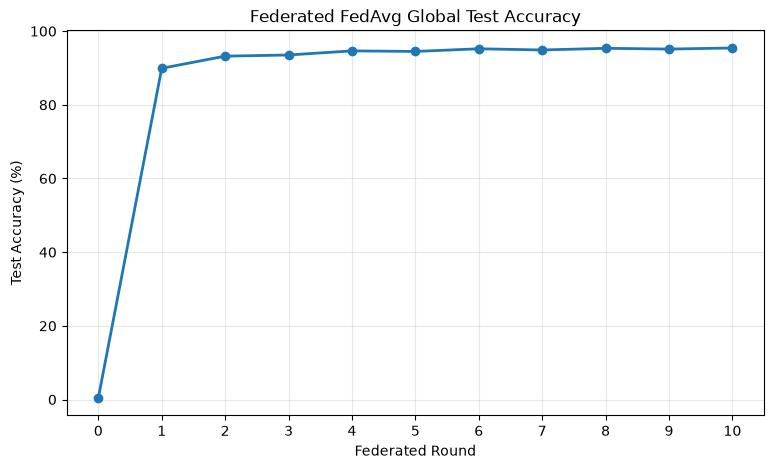

In [15]:
# ============================================================
# PLOT GLOBAL TEST ACCURACY ACROSS FEDERATED ROUNDS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    results_df["Round"],
    results_df["Accuracy"] * 100,
    marker="o",
    linewidth=2,
)

plt.title("Federated FedAvg Global Test Accuracy")
plt.xlabel("Federated Round")
plt.ylabel("Test Accuracy (%)")
plt.xticks(results_df["Round"])
plt.grid(alpha=0.3)

plt.show()

In [16]:
# ============================================================
# FINAL FEDERATED MODEL PREDICTIONS AND EVALUATION METRICS
# Run this cell only after the federated simulation in Step 12.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# Confirm that Step 12 completed in this active kernel.
assert (
    "final_global_parameters" in globals()
    and final_global_parameters is not None
), (
    "Final global model parameters are missing. "
    "Run Steps 5–12 first."
)

# Recreate the final global neural-network model.
final_model = NIDSNeuralNetwork(
    NUM_FEATURES,
    NUM_CLASSES,
).to(DEVICE)

final_model_state = final_model.state_dict()

updated_final_state = {
    key: torch.tensor(value)
    for key, value in zip(
        final_model_state.keys(),
        final_global_parameters,
    )
}

final_model.load_state_dict(
    updated_final_state,
    strict=True,
)

# Create the test-data loader.
test_loader = create_data_loader(
    X_test,
    y_test,
    shuffle=False,
)

# Generate predictions using the final federated global model.
final_model.eval()

all_predictions = []

with torch.no_grad():
    for features, _ in test_loader:
        features = features.to(DEVICE)

        outputs = final_model(features)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_predictions = np.array(all_predictions)

# Calculate overall weighted metrics.
federated_accuracy = accuracy_score(
    y_test,
    all_predictions,
)

federated_precision = precision_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

federated_recall = recall_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

federated_f1 = f1_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

# Calculate class-balanced metrics.
federated_macro_recall = recall_score(
    y_test,
    all_predictions,
    average="macro",
    zero_division=0,
)

federated_macro_f1 = f1_score(
    y_test,
    all_predictions,
    average="macro",
    zero_division=0,
)

federated_balanced_accuracy = balanced_accuracy_score(
    y_test,
    all_predictions,
)

print("✅ FINAL FEDERATED LEARNING RESULTS")
print("=" * 45)
print(f"Accuracy          : {federated_accuracy:.2%}")
print(f"Precision         : {federated_precision:.2%}")
print(f"Recall            : {federated_recall:.2%}")
print(f"F1 Score          : {federated_f1:.2%}")
print(f"Macro Recall      : {federated_macro_recall:.2%}")
print(f"Macro F1          : {federated_macro_f1:.2%}")
print(f"Balanced Accuracy : {federated_balanced_accuracy:.2%}")

✅ FINAL FEDERATED LEARNING RESULTS
Accuracy          : 95.43%
Precision         : 98.50%
Recall            : 95.43%
F1 Score          : 96.75%
Macro Recall      : 92.53%
Macro F1          : 54.31%
Balanced Accuracy : 92.53%


                            precision    recall  f1-score   support

                    BENIGN     1.0000    0.9453    0.9718    419012
                       Bot     0.0618    1.0000    0.1163       390
                      DDoS     0.9447    0.9999    0.9715     25603
             DoS GoldenEye     0.6016    1.0000    0.7513      2057
                  DoS Hulk     0.9384    0.9988    0.9677     34569
          DoS Slowhttptest     0.7353    0.9904    0.8440      1046
             DoS slowloris     0.4630    0.9805    0.6289      1077
               FTP-Patator     0.6530    0.9966    0.7891      1186
                Heartbleed     0.2500    0.5000    0.3333         2
              Infiltration     0.0031    1.0000    0.0062         7
                  PortScan     0.9632    0.9983    0.9805     18139
               SSH-Patator     0.2566    0.9922    0.4078       644
  Web Attack � Brute Force     0.1694    0.9932    0.2894       294
Web Attack � Sql Injection     0.0029    0.5000

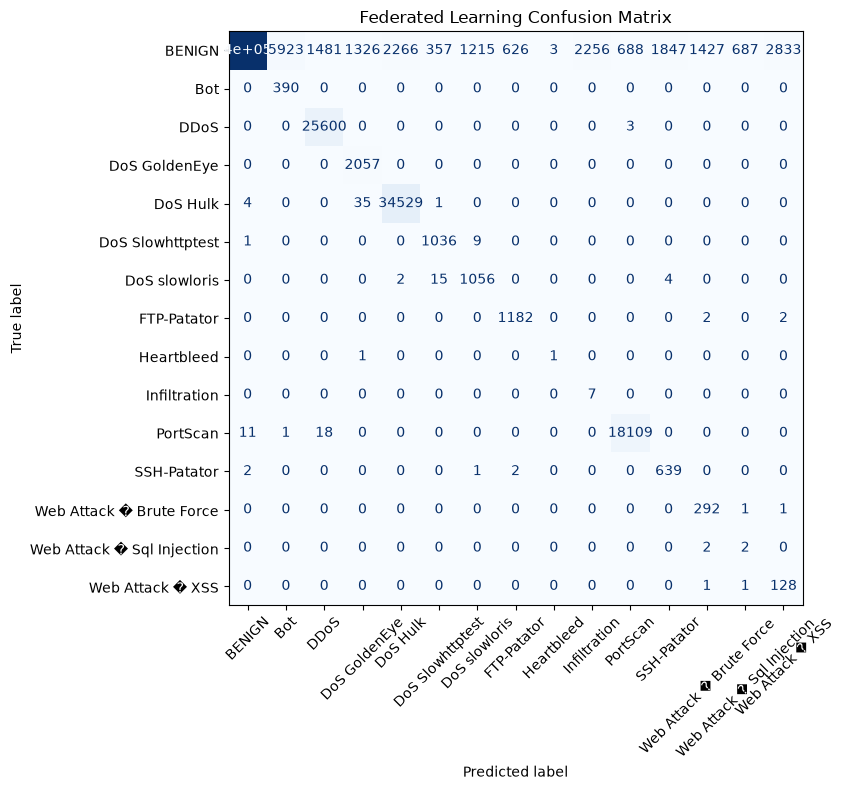

✅ Classification report and confusion matrix created.


In [17]:
# ============================================================
# CLASSIFICATION REPORT AND CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

# Convert original class labels into display text.
class_names = [
    str(label)
    for label in label_encoder.classes_
]

# Display precision, recall, and F1-score for every class.
print(
    classification_report(
        y_test,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# Create and display the confusion matrix.
confusion_matrix_values = confusion_matrix(
    y_test,
    all_predictions,
)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=class_names,
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
)

plt.title("Federated Learning Confusion Matrix")
plt.tight_layout()
plt.show()

print("✅ Classification report and confusion matrix created.")

In [18]:
# ============================================================
# SAVE FINAL FEDERATED LEARNING RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

federated_results = pd.DataFrame(
    {
        "Model": ["Federated Neural Network (FedAvg)"],
        "Training Approach": ["Federated Learning"],
        "Clients": [NUM_CLIENTS],
        "Rounds": [NUM_ROUNDS],
        "Local Epochs": [LOCAL_EPOCHS],
        "Accuracy": [federated_accuracy],
        "Precision": [federated_precision],
        "Recall": [federated_recall],
        "F1 Score": [federated_f1],
        "Macro Recall": [federated_macro_recall],
        "Macro F1": [federated_macro_f1],
        "Balanced Accuracy": [federated_balanced_accuracy],
    }
)

RESULTS_PATH = Path(
    "../results/federated_learning_results.csv"
)

RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

federated_results.to_csv(
    RESULTS_PATH,
    index=False,
)

print("✅ Federated results saved successfully.")
print("Saved to:", RESULTS_PATH.resolve())

federated_results

✅ Federated results saved successfully.
Saved to: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\federated_learning_results.csv


,Model,Training Approach,Clients,Rounds,Local Epochs,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Federated Neural Network (FedAvg),Federated Learning,4,10,2,0.95427,0.985035,0.95427,0.967487,0.92533,0.543085,0.92533


## Non-IID FedAvg Experiment

This section runs a separate FedAvg experiment using the validated `non_iid_client_partitions`. The existing IID FedAvg experiment and its results are preserved unchanged.


In [19]:
# ============================================================
# CONFIGURE NON-IID FEDAVG
# Uses the validated non_iid_client_partitions.
# Existing IID FedAvg objects/results are not overwritten.
# ============================================================

assert "non_iid_client_partitions" in globals(), (
    "non_iid_client_partitions is not available. Run the Non-IID partition cell first."
)
assert len(non_iid_client_partitions) == NUM_CLIENTS, (
    "Unexpected number of Non-IID client partitions."
)

non_iid_round_history = []
non_iid_final_global_parameters = None


def evaluate_non_iid_global_model(server_round, parameters, config):
    """
    Evaluate the Non-IID aggregated global model on the same
    centralized held-out test set used by the IID experiment.
    """
    global non_iid_final_global_parameters

    model = NIDSNeuralNetwork(
        NUM_FEATURES,
        NUM_CLASSES,
    ).to(DEVICE)

    model_state = model.state_dict()

    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }

    model.load_state_dict(updated_state, strict=True)

    loss, accuracy = evaluate_model(model, test_loader)

    non_iid_final_global_parameters = [
        parameter.copy()
        for parameter in parameters
    ]

    non_iid_round_history.append(
        {
            "Round": server_round,
            "Loss": loss,
            "Accuracy": accuracy,
        }
    )

    print(
        f"Non-IID Round {server_round:02d} | "
        f"Test Loss: {loss:.4f} | "
        f"Test Accuracy: {accuracy:.4%}"
    )

    return loss, {"accuracy": accuracy}


def non_iid_client_fn(context):
    """Create a Flower client from the validated Non-IID partition."""
    client_id = int(context.node_config["partition-id"])

    X_client, y_client = non_iid_client_partitions[client_id]

    return NIDSFlowerClient(
        X_client,
        y_client,
    ).to_client()


non_iid_strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_non_iid_global_model,
)

print("Non-IID FedAvg strategy is configured.")
print(f"Clients per round: {NUM_CLIENTS}")
print(f"Federated rounds: {NUM_ROUNDS}")
print(f"Local epochs per client: {LOCAL_EPOCHS}")


Non-IID FedAvg strategy is configured.
Clients per round: 4
Federated rounds: 10
Local epochs per client: 2


In [20]:
# ============================================================
# RUN NON-IID FEDAVG SIMULATION
# ============================================================

if ray.is_initialized():
    ray.shutdown()

print("=" * 60)
print("STARTING NON-IID FEDAVG SIMULATION")
print("=" * 60)

non_iid_history = fl.simulation.start_simulation(
    client_fn=non_iid_client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(
        num_rounds=NUM_ROUNDS,
    ),
    strategy=non_iid_strategy,
    client_resources={
        "num_cpus": 1,
    },
)

non_iid_results_df = pd.DataFrame(non_iid_round_history)

print("\n" + "=" * 60)
print("NON-IID FEDAVG SIMULATION COMPLETE")
print("=" * 60)
display(non_iid_results_df)


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout


STARTING NON-IID FEDAVG SIMULATION


2026-09-14 16:47:44,230	INFO worker.py:2024 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'GPU': 1.0, 'memory': 11328338740.0, 'node:__internal_head__': 1.0, 'object_store_memory': 4855002316.0, 'accelerator_type:GeForce-RTX-5050-Laptop-GPU': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 12 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 2.6549488580177716, {'accuracy': 0.00984013011742304}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients 

Non-IID Round 00 | Test Loss: 2.6549 | Test Accuracy: 0.9840%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.27600716333546665, {'accuracy': 0.8994644557283402}, 33.8711573999999)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (9, 0.15475127467916944, {'accuracy': 0.9572298476674072}, 287.2682874000002)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Non-IID Round 09 | Test Loss: 0.1548 | Test Accuracy: 95.7230%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (10, 0.20871008418261608, {'accuracy': 0.9450829101872421}, 319.37982889999967)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 319.38s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.6549488580177716
INFO :      		round 1: 0.27600716333546665
INFO :      		round 2: 0.22417415902751547
INFO :      		round 3: 0.18091233641391555
INFO :      		round 4: 0.16661007453698426
INFO :      		round 5: 0.14659865744735884
INFO :      		round 6: 0.1721621320616325
INFO :      		round 7: 0.15749665973243998
INFO :      		round 8: 0.23013821305149662
INFO :      		round 9: 0.15475127467916944
INFO :      		round 10: 0.20871008418261608
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.00984013011742304),
INFO :      	              (1, 0.8994644557283402),
INFO :      	

Non-IID Round 10 | Test Loss: 0.2087 | Test Accuracy: 94.5083%

NON-IID FEDAVG SIMULATION COMPLETE


,Round,Loss,Accuracy
0,0,2.654949,0.009840
1,1,0.276007,0.899464
2,2,0.224174,0.921219
3,3,0.180912,0.940727
4,4,0.166610,0.949873
5,5,0.146599,0.957736
6,6,0.172162,0.950698
7,7,0.157497,0.955469
8,8,0.230138,0.947346
9,9,0.154751,0.957230


In [21]:
# ============================================================
# SAVE NON-IID FEDAVG ROUND HISTORY
# ============================================================

NON_IID_RESULTS_PATH = Path(
    "../results/non_iid_federated_learning_results.csv"
)

NON_IID_RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

non_iid_results_df.to_csv(
    NON_IID_RESULTS_PATH,
    index=False,
)

print("Saved:", NON_IID_RESULTS_PATH.resolve())
print("\nNon-IID FedAvg round history:")
display(non_iid_results_df)


Saved: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\non_iid_federated_learning_results.csv

Non-IID FedAvg round history:


,Round,Loss,Accuracy
0,0,2.654949,0.009840
1,1,0.276007,0.899464
2,2,0.224174,0.921219
3,3,0.180912,0.940727
4,4,0.166610,0.949873
5,5,0.146599,0.957736
6,6,0.172162,0.950698
7,7,0.157497,0.955469
8,8,0.230138,0.947346
9,9,0.154751,0.957230


In [22]:
# ============================================================
# NON-IID FEDAVG FINAL RESULT
# ============================================================

valid_results = non_iid_results_df.dropna(subset=["Accuracy", "Loss"])
assert not valid_results.empty, "No valid Non-IID evaluation results were produced."

final_non_iid_accuracy = valid_results["Accuracy"].iloc[-1]
final_non_iid_loss = valid_results["Loss"].iloc[-1]

print("=" * 60)
print("NON-IID FEDAVG FINAL RESULT")
print("=" * 60)
print(f"Final Round: {NUM_ROUNDS}")
print(f"Final Loss: {final_non_iid_loss:.6f}")
print(f"Final Accuracy: {final_non_iid_accuracy:.6%}")
print("\nExisting IID FedAvg results remain unchanged.")


NON-IID FEDAVG FINAL RESULT
Final Round: 10
Final Loss: 0.208710
Final Accuracy: 94.508291%

Existing IID FedAvg results remain unchanged.


# IID vs Non-IID Comparative Evaluation

Both final global models are evaluated on the same centralized CICIDS2017 test set using the same metrics and methodology.

In [23]:
# ============================================================
# IID vs NON-IID EVALUATION ON THE SAME TEST SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
)

assert final_global_parameters is not None, (
    "IID final model parameters are unavailable. Run the existing IID FedAvg experiment first."
)
assert non_iid_final_global_parameters is not None, (
    "Non-IID final model parameters are unavailable. Run the Non-IID FedAvg experiment first."
)
assert len(X_test) == len(y_test), "Test features and labels have different lengths."


def load_global_model(parameters):
    """Load Flower model parameters into the NIDS neural network."""
    model = NIDSNeuralNetwork(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
    model_state = model.state_dict()
    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }
    model.load_state_dict(updated_state, strict=True)
    model.eval()
    return model


def predict_model(model, loader):
    """Generate predictions on a supplied evaluation DataLoader."""
    predictions = []
    targets = []

    model.eval()
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE)
            outputs = model(features)
            predictions.extend(outputs.argmax(dim=1).cpu().numpy())
            targets.extend(labels.numpy())

    return np.asarray(targets), np.asarray(predictions)


iid_model = load_global_model(final_global_parameters)
non_iid_model = load_global_model(non_iid_final_global_parameters)

y_true_iid, y_pred_iid = predict_model(iid_model, test_loader)
y_true_non_iid, y_pred_non_iid = predict_model(non_iid_model, test_loader)

# Confirm both experiments used exactly the same centralized test labels.
assert np.array_equal(y_true_iid, y_test)
assert np.array_equal(y_true_non_iid, y_test)
assert np.array_equal(y_true_iid, y_true_non_iid)

print("✅ Both models evaluated on the same centralized test set.")
print(f"Test samples evaluated: {len(y_test):,}")


✅ Both models evaluated on the same centralized test set.
Test samples evaluated: 504,160


# IID vs Non-IID Metrics Comparison


In [24]:
# ============================================================
# OVERALL METRICS
# Precision / Recall / F1 = weighted averages.
# Macro metrics are reported separately for class-balanced analysis.
# ============================================================

def calculate_metrics(y_true, y_pred, experiment):
    return {
        "Experiment": experiment,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
    }

comparison_results = pd.DataFrame([
    calculate_metrics(y_true_iid, y_pred_iid, "IID FedAvg"),
    calculate_metrics(y_true_non_iid, y_pred_non_iid, "Non-IID FedAvg"),
])

metric_columns = [column for column in comparison_results.columns if column != "Experiment"]
comparison_results_percent = comparison_results.copy()
comparison_results_percent[metric_columns] = (
    comparison_results_percent[metric_columns] * 100
).round(2)

display(comparison_results_percent)


,Experiment,Accuracy,Precision,Recall,F1,Macro F1,Macro Recall,Balanced Accuracy
0,IID FedAvg,95.43,98.50,95.43,96.75,54.31,92.53,92.53
1,Non-IID FedAvg,94.51,98.42,94.51,96.22,57.33,89.61,89.61


# Absolute IID vs Non-IID Performance Difference


In [25]:
# ============================================================
# ABSOLUTE PERFORMANCE DIFFERENCE
# Positive value means IID FedAvg scored higher.
# ============================================================

difference_df = pd.DataFrame({
    "Metric": metric_columns,
    "IID": comparison_results_percent.loc[0, metric_columns].values,
    "Non-IID": comparison_results_percent.loc[1, metric_columns].values,
})

difference_df["Absolute Difference (pp)"] = (
    difference_df["IID"] - difference_df["Non-IID"]
).round(2)

display(difference_df)


,Metric,IID,Non-IID,Absolute Difference (pp)
0,Accuracy,95.43,94.51,0.92
1,Precision,98.50,98.42,0.08
2,Recall,95.43,94.51,0.92
3,F1,96.75,96.22,0.53
4,Macro F1,54.31,57.33,-3.02
5,Macro Recall,92.53,89.61,2.92
6,Balanced Accuracy,92.53,89.61,2.92


# Per-Class IID vs Non-IID Performance


In [26]:
# ============================================================
# PER-CLASS METRICS
# ============================================================

iid_report = pd.DataFrame(
    classification_report(
        y_true_iid,
        y_pred_iid,
        labels=np.arange(NUM_CLASSES),
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose()

non_iid_report = pd.DataFrame(
    classification_report(
        y_true_non_iid,
        y_pred_non_iid,
        labels=np.arange(NUM_CLASSES),
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
).transpose()

class_labels = list(label_encoder.classes_)

per_class_metrics = pd.DataFrame({
    "Class": class_labels,
    "IID Precision": iid_report.loc[class_labels, "precision"].values,
    "Non-IID Precision": non_iid_report.loc[class_labels, "precision"].values,
    "IID Recall": iid_report.loc[class_labels, "recall"].values,
    "Non-IID Recall": non_iid_report.loc[class_labels, "recall"].values,
    "IID F1": iid_report.loc[class_labels, "f1-score"].values,
    "Non-IID F1": non_iid_report.loc[class_labels, "f1-score"].values,
})

per_class_metrics["F1 Difference (pp)"] = (
    (per_class_metrics["IID F1"] - per_class_metrics["Non-IID F1"]) * 100
).round(2)

display(per_class_metrics.round(4))


,Class,IID Precision,Non-IID Precision,IID Recall,Non-IID Recall,IID F1,Non-IID F1,F1 Difference (pp)
0,BENIGN,1.0000,0.9999,0.9453,0.9345,0.9718,0.9661,0.57
1,Bot,0.0618,0.0419,1.0000,1.0000,0.1163,0.0804,3.59
2,DDoS,0.9447,0.9456,0.9999,0.9999,0.9715,0.9720,-0.05
3,DoS GoldenEye,0.6016,0.6651,1.0000,1.0000,0.7513,0.7988,-4.76
4,DoS Hulk,0.9384,0.9397,0.9988,0.9986,0.9677,0.9682,-0.06
5,DoS Slowhttptest,0.7353,0.6809,0.9904,0.9914,0.8440,0.8073,3.67
6,DoS slowloris,0.4630,0.6671,0.9805,0.9805,0.6289,0.7940,-16.50
7,FTP-Patator,0.6530,0.5718,0.9966,0.9966,0.7891,0.7267,6.23
8,Heartbleed,0.2500,1.0000,0.5000,1.0000,0.3333,1.0000,-66.67
9,Infiltration,0.0031,0.0078,1.0000,1.0000,0.0062,0.0154,-0.92


# Save IID vs Non-IID Results and Visualizations


✅ Saved comparison CSV artifacts.


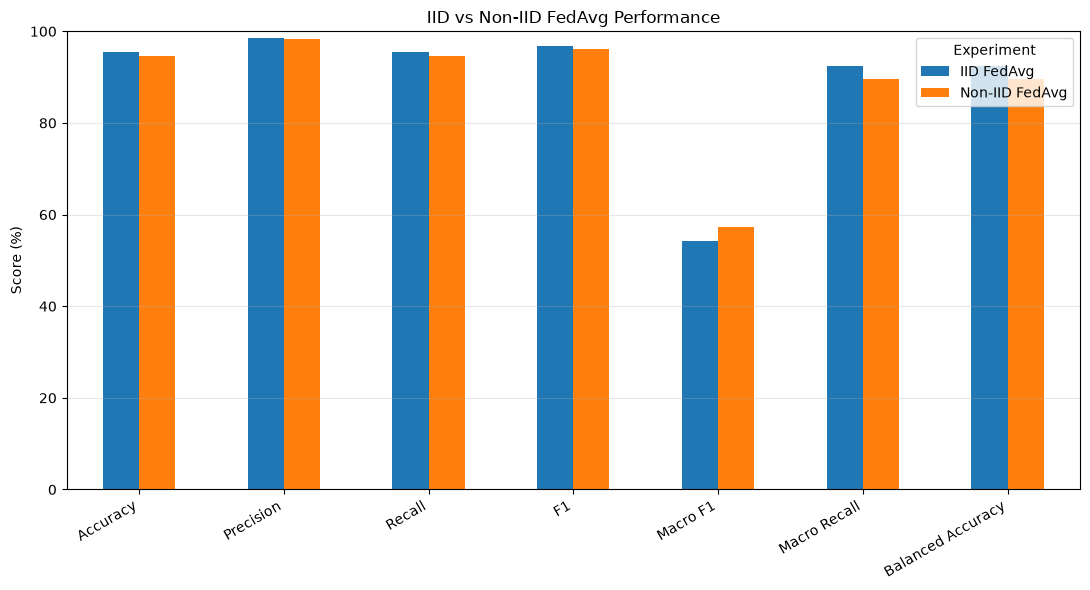

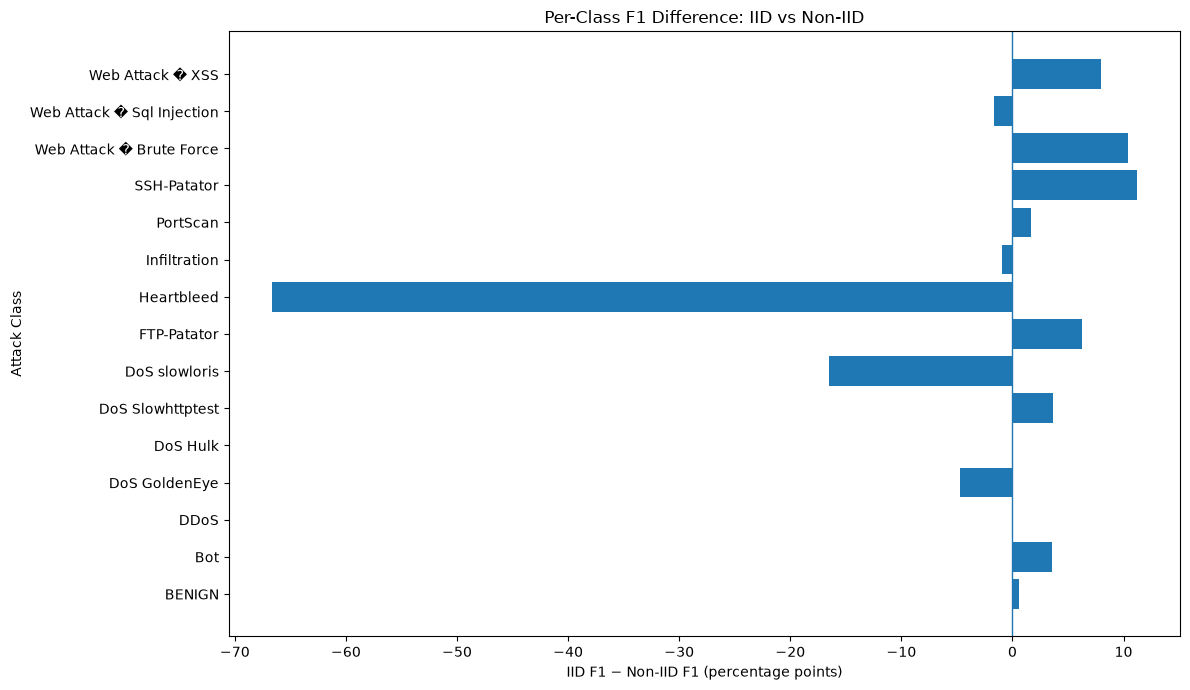

✅ Visualizations saved.


In [27]:
# ============================================================
# SAVE CSV ARTIFACTS
# ============================================================

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

comparison_results_percent.to_csv(
    RESULTS_DIR / "iid_vs_non_iid_metrics.csv",
    index=False,
)

difference_df.to_csv(
    RESULTS_DIR / "iid_vs_non_iid_difference.csv",
    index=False,
)

per_class_metrics.to_csv(
    RESULTS_DIR / "iid_vs_non_iid_per_class_metrics.csv",
    index=False,
)

print("✅ Saved comparison CSV artifacts.")

# ============================================================
# OVERALL METRICS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

ax = comparison_results_percent.set_index("Experiment")[metric_columns].T.plot(
    kind="bar",
    figsize=(11, 6),
)
ax.set_ylabel("Score (%)")
ax.set_title("IID vs Non-IID FedAvg Performance")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "iid_vs_non_iid_metrics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# ============================================================
# PER-CLASS F1 DIFFERENCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))
plt.barh(
    per_class_metrics["Class"],
    per_class_metrics["F1 Difference (pp)"],
)
plt.axvline(0, linewidth=1)
plt.xlabel("IID F1 − Non-IID F1 (percentage points)")
plt.ylabel("Attack Class")
plt.title("Per-Class F1 Difference: IID vs Non-IID")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "iid_vs_non_iid_per_class_f1_difference.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("✅ Visualizations saved.")
